In [1]:
print('hello')

hello


In [2]:
# downloading the libraries

import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import pandas as pd
pd.set_option('display.max_columns', 100)
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap # correlation matrix

# worldcloud
import random
from wordcloud import WordCloud

# display ERD
from IPython.display import Image



# I - Exploring the data 

objective is to get more familiar with the data and review pandas / visulization logic

## A - Fetching the data 

In [6]:
# adding the path to fetch the files
raw_path = r'C:\Users\louis\Desktop\Albert School x Les Mines\Cours\Head of Data\olist_datasets'

In [7]:
# creating pandas dataframes from .csv
df_customer = pd.read_csv(raw_path + '/olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + '/olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + '/olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + '/olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + '/olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + '/olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + '/olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + '/olist_sellers_dataset.csv')

## B - Exploring the orders dataframe

In [8]:
# printing columns, null count, and dtypes for the orders dataframe

print(df_orders.columns)
print(df_orders.isnull().sum())
print(df_orders.dtypes)

print(df_orders.head())


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef43

In [9]:
# printing the first 10 lines of the orders dataframe
print('First 10 lines of the orders dataframe:')
print(df_orders.head(10))

# the last 10 lines of the dataframe
print('Last 10 lines of the orders dataframe:')
print(df_orders.tail(10))

# a sample of ten lines
print('A sample of 10 lines from the orders dataframe:')
print(df_orders.sample(10))

# getting all null values
print('Null values in the orders dataframe:')
print(df_orders.isnull())


First 10 lines of the orders dataframe:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
5  a4591c265e18cb1dcee52889e2d8acc3  503740e9ca751ccdda7ba28e9ab8f608   
6  136cce7faa42fdb2cefd53fdc79a6098  ed0271e0b7da060a393796590e7b737a   
7  6514b8ad8028c9f2cc2374ded245783f  9bdf08b4b3b52b5526ff42d37d47f222   
8  76c6e866289321a7c93b82b54852dc33  f54a9f0e6b351c431402b8461ea51999   
9  e69bfb5eb88e0ed6a785585b27e16dbf  31ad1d1b63eb9962463f764d4e6e0c9d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-

**why are there null values for approved_at, delivered_carrier_date, delivered_customer_date?**

*-> answer:*

In [10]:
# fetching only particular columns of the df_orders dataframe

## fetch the order_approved_at columns in a data series format, then in a dataframe format, and print the first five lines

print('Order Approved At (Series):')
order_approved_at_series = df_orders['order_approved_at']
print(order_approved_at_series.head())

print('Order Approved At (DataFrame):')
order_approved_at_df = df_orders[['order_approved_at']]
print(order_approved_at_df.head())

## fetch the order_id, order_status, approved_at, delivered_carrier_date, delivered_customer_date

print(df_orders[['order_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']])

Order Approved At (Series):
0    2017-10-02 11:07:15
1    2018-07-26 03:24:27
2    2018-08-08 08:55:23
3    2017-11-18 19:45:59
4    2018-02-13 22:20:29
Name: order_approved_at, dtype: object
Order Approved At (DataFrame):
     order_approved_at
0  2017-10-02 11:07:15
1  2018-07-26 03:24:27
2  2018-08-08 08:55:23
3  2017-11-18 19:45:59
4  2018-02-13 22:20:29
                               order_id order_status    order_approved_at  \
0      e481f51cbdc54678b7cc49136f2d6af7    delivered  2017-10-02 11:07:15   
1      53cdb2fc8bc7dce0b6741e2150273451    delivered  2018-07-26 03:24:27   
2      47770eb9100c2d0c44946d9cf07ec65d    delivered  2018-08-08 08:55:23   
3      949d5b44dbf5de918fe9c16f97b45f8a    delivered  2017-11-18 19:45:59   
4      ad21c59c0840e6cb83a9ceb5573f8159    delivered  2018-02-13 22:20:29   
...                                 ...          ...                  ...   
99436  9c5dedf39a927c1b2549525ed64a053c    delivered  2017-03-09 09:54:05   
99437  63943bddc261676b

In [12]:
# fetching the approved_at null columns - create another dataframe df_filtered, which will be filtered on order_approved_at is null, and print first 10 rows

df_filtered = df_orders[df_orders['order_approved_at'].isnull()]
print(df_filtered.head(10))


                              order_id                       customer_id  \
1130  00b1cb0320190ca0daa2c88b35206009  3532ba38a3fd242259a514ac2b6ae6b6   
1801  ed3efbd3a87bea76c2812c66a0b32219  191984a8ba4cbb2145acb4fe35b69664   
1868  df8282afe61008dc26c6c31011474d02  aa797b187b5466bc6925aaaa4bb3bed1   
2029  8d4c637f1accf7a88a4555f02741e606  b1dd715db389a2077f43174e7a675d07   
2161  7a9d4c7f9b068337875b95465330f2fc  7f71ae48074c0cfec9195f88fcbfac55   
3056  ddaec6fff982b13e7e048b627a11d6da  68f4ad79cc0c2ad06e19088f5c00e9fa   
3094  5290c34bd38a8a095b885f13958db1e1  92af427e290117f39d9ff908566072e0   
3684  03310aa823a66056268a3bab36e827fb  25dbbf0c477fd4ae0880aaffbb12e8b3   
4373  4c8b9947280829d0a8b7e81cc249b875  403c35c4d8813bf67b3d396b91ca1619   
4939  b13ea375fe9c728832688264638f84cf  0dc5884bc5ffba283678229f27e07ff9   

     order_status order_purchase_timestamp order_approved_at  \
1130     canceled      2018-08-28 15:26:39               NaN   
1801     canceled      2018-09-20 1

In [13]:
# count the order_id with a null approved_at by order_status

# with groupby method

null_by_status = df_orders[df_orders['order_approved_at'].isnull()].groupby('order_status')['order_id'].count()
print(null_by_status)

# with value_counts method

print(df_orders[df_orders['order_approved_at'].isnull()]['order_status'].value_counts())


order_status
canceled     141
created        5
delivered     14
Name: order_id, dtype: int64
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64


**what do you think of the results? Why is there a null approved at to begin with?**

-> *answer*: most null approved_at are canceled orders - makes sense since they never got approved


## C - Creating a simple visualization using Matplotlib or Seaborn

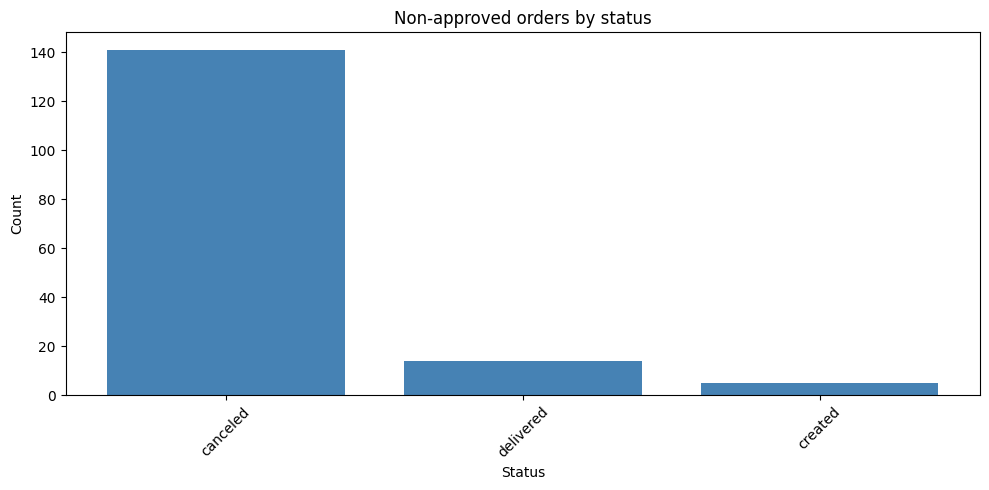

In [14]:
# Creating a simple plot with matplotlib: count of non-approved orders by status
non_approved = df_orders[df_orders['order_approved_at'].isnull()]
status_counts = non_approved['order_status'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(status_counts.index, status_counts.values, color='steelblue')
plt.title('Non-approved orders by status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


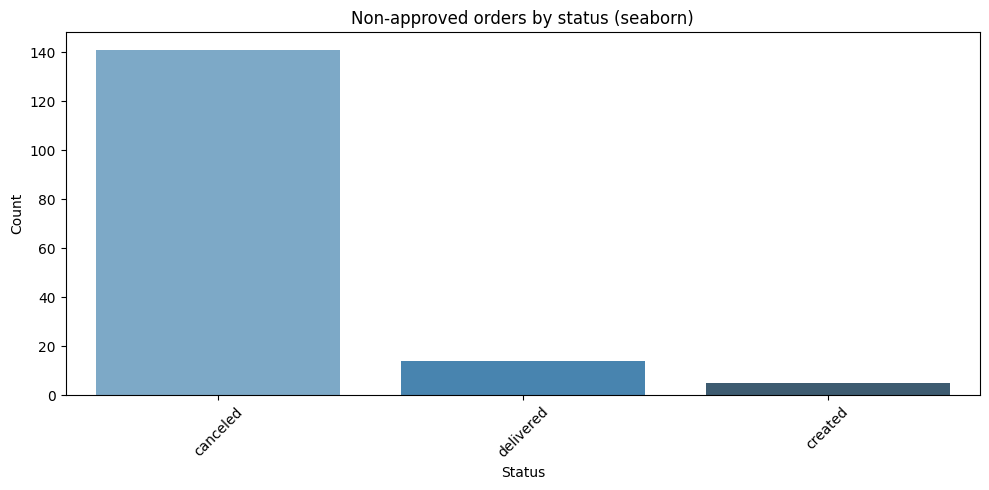

In [15]:
# Creating a simple plot with seaborn: count of non-approved orders by status
plt.figure(figsize=(10, 5))
sns.countplot(data=non_approved, x='order_status', hue='order_status', palette='Blues_d', legend=False)
plt.title('Non-approved orders by status (seaborn)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## D - Exploring all dataframes at once

In [16]:
# an interesting way to look at all dataframes at once, to quickly get what are the null columns

# Collections for each dataset
datasets = [df_customer, df_geolocation, df_orders, df_order_items, df_order_payments,
            df_order_reviews, df_products, df_sellers]
names = ['df_customer', 'df_geolocation', 'df_orders', 'df_order_items', 'df_order_payments',
         'df_order_reviews', 'df_products', 'df_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()


,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,df_customer,99441,5,0,0,
1,df_geolocation,1000163,5,0,0,
2,df_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,df_order_items,112650,7,0,0,
4,df_order_payments,103886,5,0,0,
5,df_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,df_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,df_sellers,3095,4,0,0,


**What are the dataframes with the most null columns? What's your explanation?**

*->answer:* df_products has the most null columns (description, dimensions etc. not always filled)

## E - Joining 2 dataframes - how many orders were created in SP state?

In [17]:
# which dataframes do we need to join to answer the question? Explore the dataframes and look for a link between orders and state

print(df_orders.columns)
print(df_customer.columns)


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')


In [18]:
# Merge the 2 datasets in a new df_merged dataset, and print the first 5 rows

df_merged = pd.merge(df_orders, df_customer, on='customer_id', how='inner')
print(df_merged.head(5))


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [19]:
# filter the dataframe to have only rows with state = SP, and print the first 5 lines

df_sp = df_merged[df_merged['customer_state'] == 'SP']
print(df_sp.head(5))
print(f"Orders from SP: {len(df_sp)}")


                            order_id                       customer_id  \
0   e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
4   ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
9   e69bfb5eb88e0ed6a785585b27e16dbf  31ad1d1b63eb9962463f764d4e6e0c9d   
11  34513ce0c4fab462a55830c0989c7edb  7711cf624183d843aafe81855097bc37   
13  5ff96c15d0b717ac6ad1f3d77225a350  19402a48fe860416adf93348aba37740   

   order_status order_purchase_timestamp    order_approved_at  \
0     delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
4     delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   
9     delivered      2017-07-29 11:55:02  2017-07-29 12:05:32   
11    delivered      2017-07-13 19:58:11  2017-07-13 20:10:08   
13    delivered      2018-07-25 17:44:10  2018-07-25 17:55:14   

   order_delivered_carrier_date order_delivered_customer_date  \
0           2017-10-04 19:55:00           2017-10-10 21:25:13   
4           2018-02-14 19:46:34   

In [20]:
# count the number of orders by state, using both groupby and value_counts

# with groupby method
orders_by_state = df_merged.groupby('customer_state')['order_id'].count().sort_values(ascending=False)
print(orders_by_state)


# with value_counts method
print(df_merged['customer_state'].value_counts())


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


# II - Exploratory analysis 

our objective is to a) give an overview of the business, b) understand what's driving the bad reviews

## A - Creating a uniform dataframe for our analysis

**Creating an ERD of the database**

- in an ERD diagram tool 
- create one item per table
- list all columns
- list their type
- find the primary and foreign keys
- link the tables together

--> upload directly the ERD in the notebook 

In [ ]:
# Displaying the image with Ipython Image module

## the image is in the data/ERD folder
filename = '../data/ERD/olist_erd.png'

Image(filename=filename)


In [23]:
# Merging the dataframes using the ERD above
df = df_orders.copy()
df = df.merge(df_customer, on='customer_id', how='left')
df = df.merge(df_order_items, on='order_id', how='left')
df = df.merge(df_products, on='product_id', how='left')
df = df.merge(df_sellers, on='seller_id', how='left')
df = df.merge(df_order_payments, on='order_id', how='left')
df = df.merge(df_order_reviews, on='order_id', how='left')

print(f"merged df shape: {df.shape}")


merged df shape: (119143, 39)


In [42]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'], errors='coerce')
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], errors='coerce')

df['delivery_time'] = (df['order_delivered_customer_date'] -
                       df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['week'] = df['order_purchase_timestamp'].dt.isocalendar().week
df['day_of_week_int'] = df['order_purchase_timestamp'].dt.dayofweek + 1
df['hour'] = df['order_purchase_timestamp'].dt.hour
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

print("done")
df.head()

done


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,year,month,week,day_of_week_int,hour,year_month,is_delivered,is_late,days_late,is_bad_review,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaT,2017-10-02 11:07:15,2017-10-04 19:55:00,NaT,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,NaN,NaN,NaN,<NA>,NaN,NaN,NaT,1,0,0.0,0,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaT,2017-10-02 11:07:15,2017-10-04 19:55:00,NaT,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,NaN,NaN,NaN,<NA>,NaN,NaN,NaT,1,0,0.0,0,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaT,2017-10-02 11:07:15,2017-10-04 19:55:00,NaT,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,NaN,NaN,NaN,<NA>,NaN,NaN,NaT,1,0,0.0,0,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,NaT,2018-07-26 03:24:27,2018-07-26 14:31:00,NaT,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,NaN,NaN,NaN,<NA>,NaN,NaN,NaT,1,0,0.0,0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,NaT,2018-08-08 08:55:23,2018-08-08 13:50:00,NaT,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,NaN,NaN,NaN,<NA>,NaN,NaN,NaT,1,0,0.0,0,179.12


## B - Looking at Reviews


### 1 - Let's look at the distribution of the review score

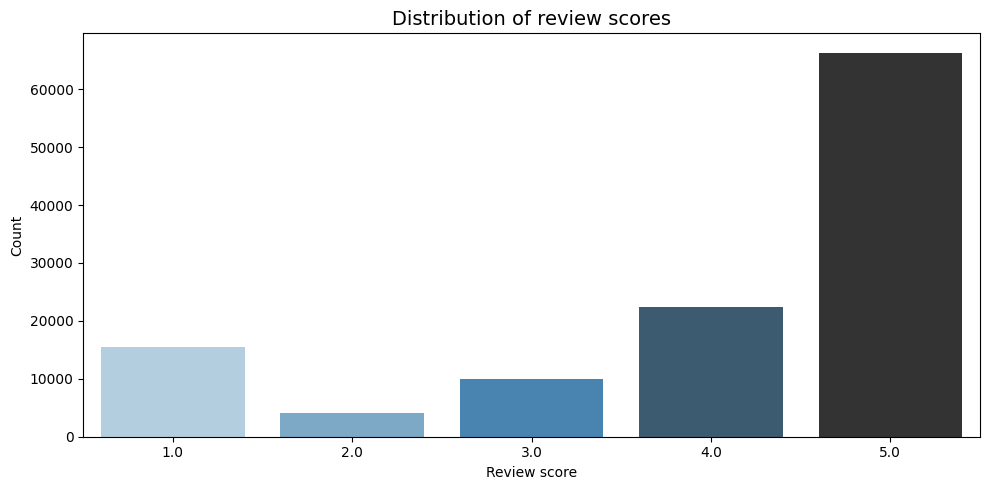

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64


In [34]:
# Create a distribution plot (dist plot) with seaborn on the review score

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='review_score', hue='review_score', palette='Blues_d', legend=False)
plt.title('Distribution of review scores', fontsize=14)
plt.xlabel('Review score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['review_score'].value_counts().sort_index())



**What do you make of those results?**

*->answer:*most reviews are 5 stars which is a good sign, but there's a significant chunk of 1 star reviews



### 2 - Let's look at the customer verbatims

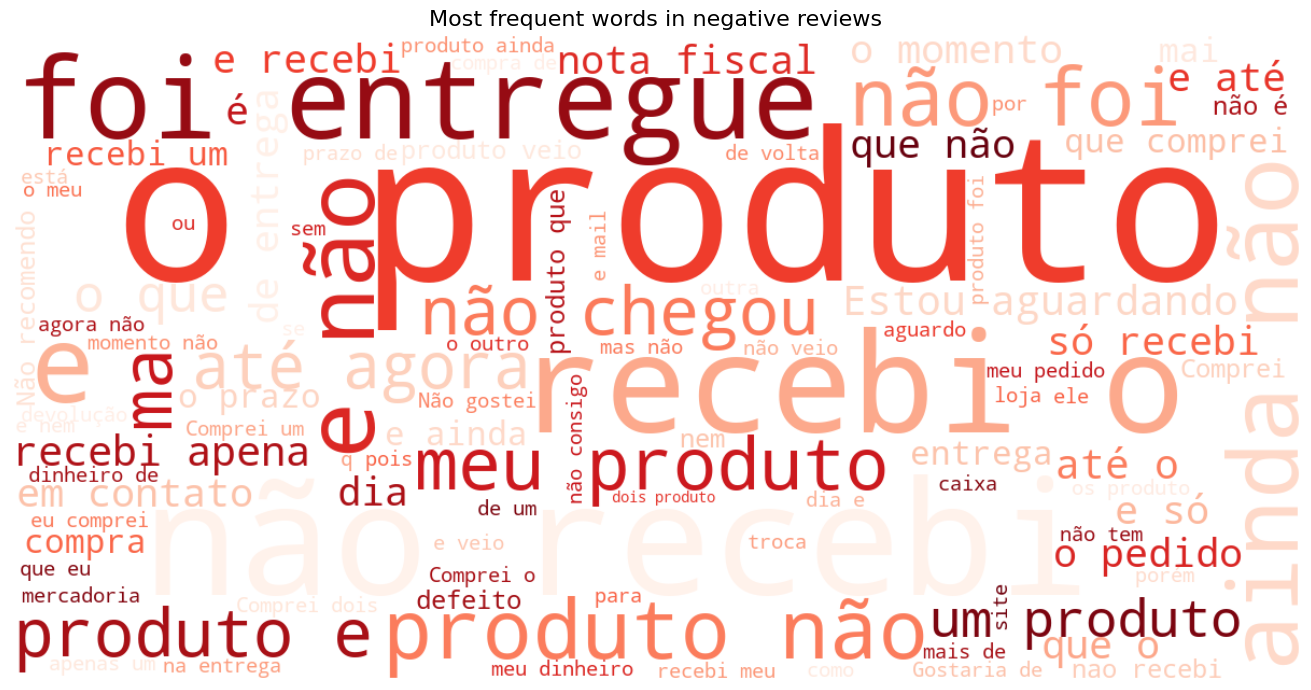

In [26]:
# Create a wordcloud on orders with negative reviews only
negative_reviews = df[df['review_score'] <= 2]['review_comment_message'].dropna()
text = ' '.join(negative_reviews.astype(str))

wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      colormap='Reds', max_words=100).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in negative reviews', fontsize=16)
plt.tight_layout()
plt.show()

**What are the first reasons you see behind a bad review? What could we do to improve this wordcloud?**

*-> answer:*delivery delays and product quality seem to be the main issues

### 3 - Let's create a correlation matrix and identify other reasons behind bad reviews

In [37]:
# let's isolate the columns we'll use for our correlation matrix
print(df.dtypes)

# bonus: can we create additional features?
# is_delivered : 1 if the order was actually delivered
df['is_delivered'] = (df['order_status'] == 'delivered').astype(int)

# convert both columns to datetime before comparing
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')

# is_late compare actual delivery vs estimated
df['is_late'] = ((df['order_delivered_customer_date'] > df['order_estimated_delivery_date']) &
                 (df['is_delivered'] == 1)).astype(int)

# days_late how many days late (0 if on time)
df['days_late'] = ((df['order_delivered_customer_date'] - df['order_estimated_delivery_date'])
                   .dt.total_seconds() / (24 * 3600)).clip(lower=0).fillna(0)

df['is_bad_review'] = (df['review_score'] <= 2).astype(int)
df['order_value'] = df['price'] + df['freight_value']






order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp                 object
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
order_item_id                           float64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              

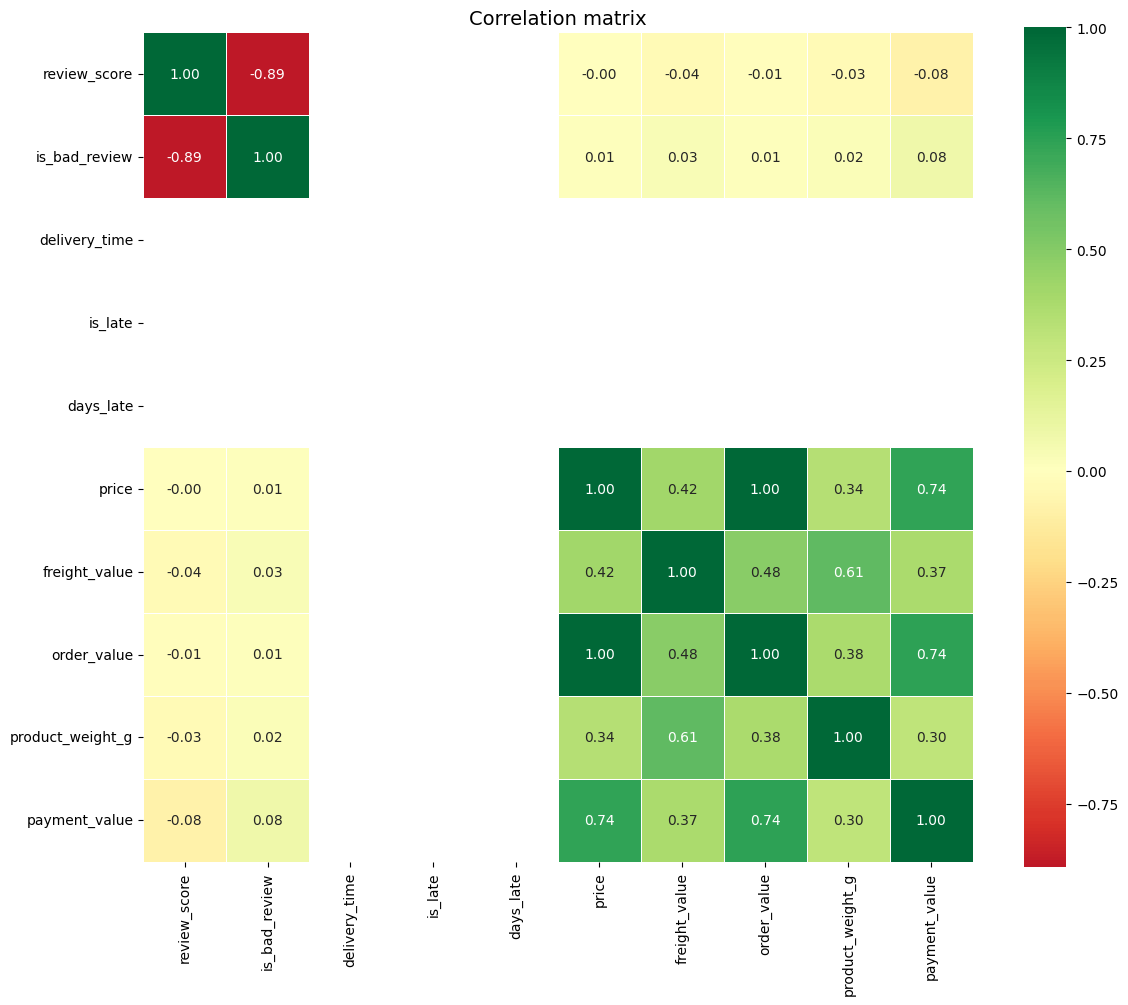

In [43]:
# Create the correlation matrix based on the columns you want
colors = ['#001F3F', '#0074D9', '#7FDBFF', '#39CCCC', '#3D9970', '#2ECC40', '#01FF70']

correlation_features = df[['review_score', 'is_bad_review', 'delivery_time',
                            'is_late', 'days_late', 'price', 'freight_value',
                            'order_value', 'product_weight_g', 'payment_value']]

# Calculate the correlation matrix
correlation = correlation_features.corr()

# use seaborn to print the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation matrix', fontsize=14)
plt.tight_layout()
plt.show()

**What are the correlations you see?**

*-> answer:*delivery time and being late are negatively correlated with review score

## C - Looking at orders

### 1 - Orders by statuses

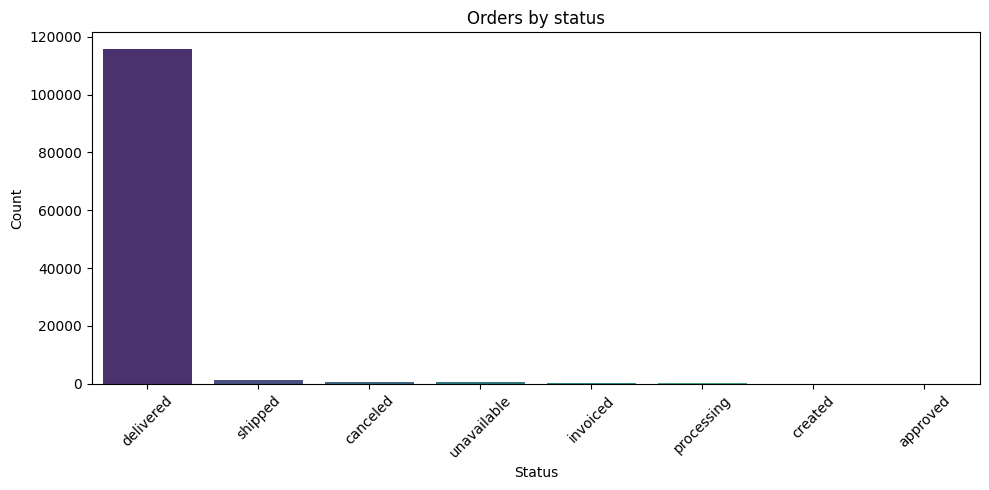

In [45]:
# Create a visualization to count the orders by statuses


plt.figure(figsize=(10, 5))
status_counts = df['order_status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, hue=status_counts.index, palette='viridis', legend=False)
plt.title('Orders by status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2 - Evolution of total orders over time

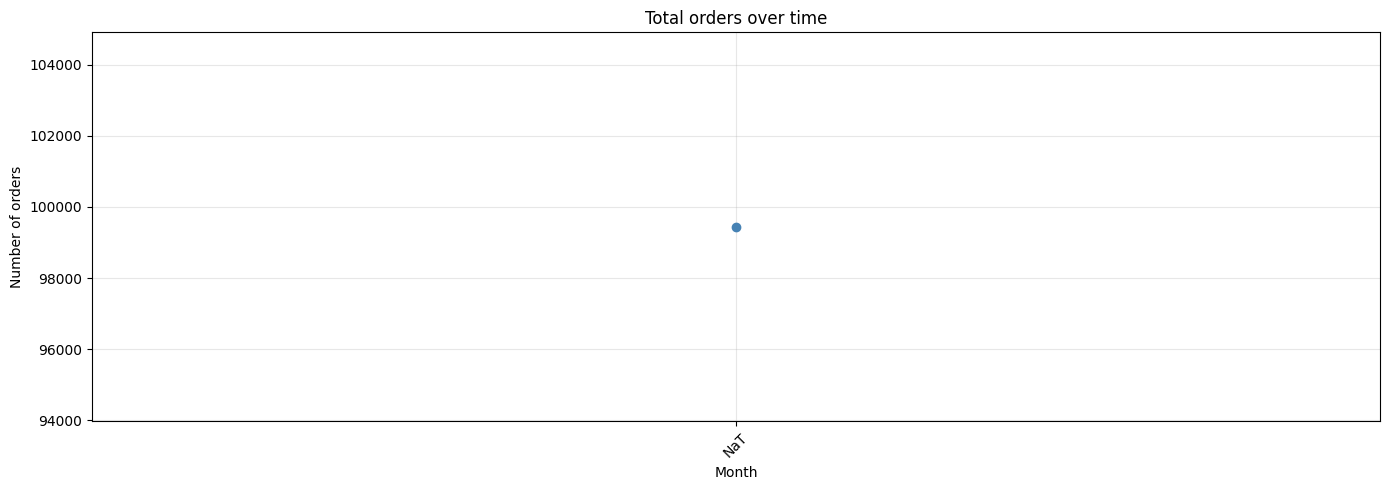

In [46]:
# Create a visualization to see the evolution of orders over time
orders_over_time = df.groupby('year_month')['order_id'].nunique().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(orders_over_time.index, orders_over_time.values, marker='o', color='steelblue', linewidth=2)
plt.title('Total orders over time')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3 - Comparing 2017 and 2018 (bonus)

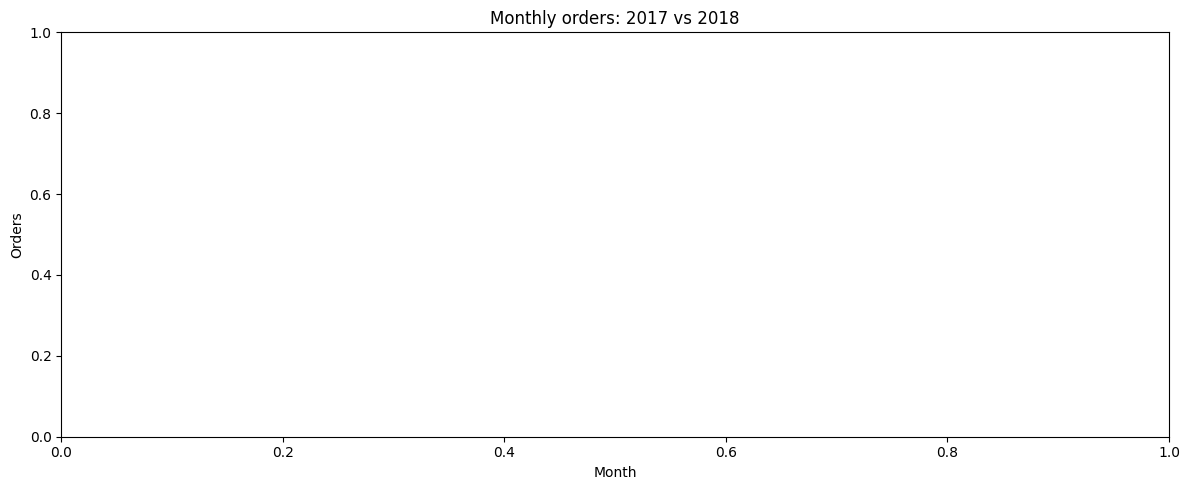

In [47]:
# Create a visualization to compare 2017 and 2018 on the same graph (bar charts with a "hue" = 'year'
df_17_18 = df[df['year'].isin([2017, 2018])].copy()
orders_per_month = df_17_18.groupby(['month', 'year'])['order_id'].nunique().reset_index()
orders_per_month.columns = ['month', 'year', 'order_count']

plt.figure(figsize=(12, 5))
sns.barplot(data=orders_per_month, x='month', y='order_count', hue='year', palette=['#E74C3C', '#3498DB'])
plt.title('Monthly orders: 2017 vs 2018')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()



## D - Delivery times

### 1 - Delivery time by product category

In [48]:
# Start by counting the orders by product category, and create an 'Other section' for product categories that have the lowest amount of orders

# Count the occurrences of each product category
category_counts = df['product_category_name'].value_counts()

# Only keep the product category that are above a certain threshold, put the others in a "Other' category
threshold = 3000  
threshold = 3000
df['category_grouped'] = df['product_category_name'].apply(
    lambda x: x if x in category_counts[category_counts >= threshold].index else 'Other'
)


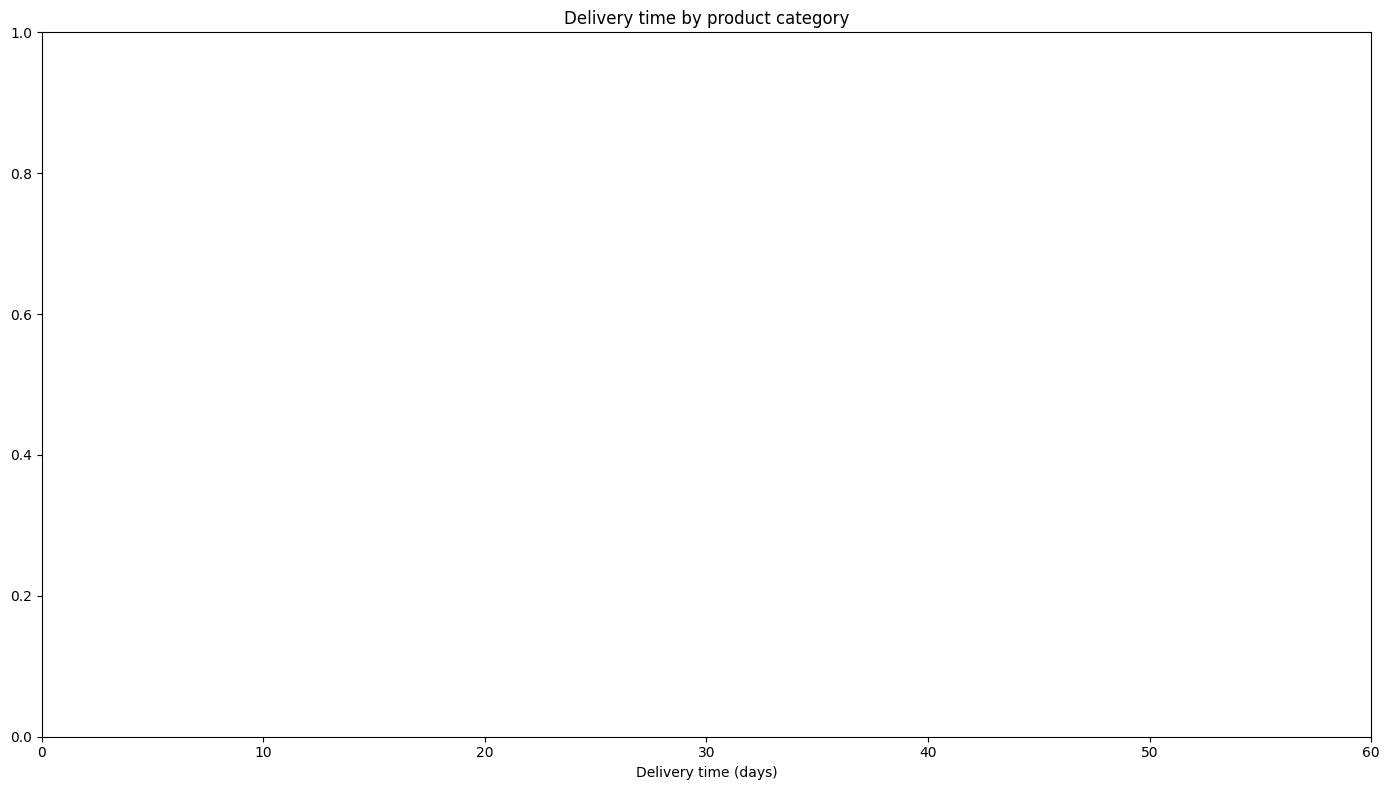

In [49]:
# Create a boxplot visualization that shows the delivery time by product category

df_delivery = df[df['delivery_time'].notna()].copy()
category_order = df_delivery.groupby('category_grouped')['delivery_time'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_delivery, y='category_grouped', x='delivery_time',
            order=category_order, palette='Set2')
plt.title('Delivery time by product category')
plt.xlabel('Delivery time (days)')
plt.xlim(0, 60)
plt.tight_layout()
plt.show()



### 2 - Delivery time by day of the week

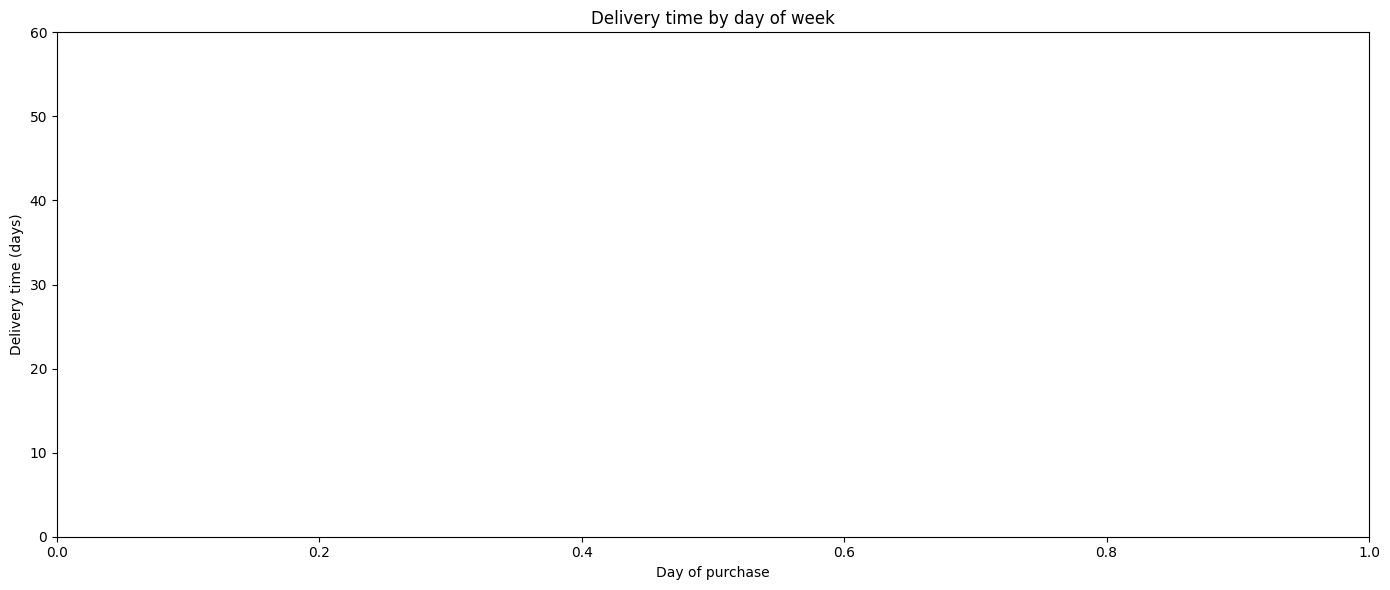

In [51]:
# Create a violin box plot visualization to see the delivery time by day of the week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_delivery['day_name'] = df_delivery['day_of_week_int'].apply(
    lambda x: day_names[int(x)-1] if pd.notna(x) and 1 <= x <= 7 else 'Unknown'
)

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_delivery, x='day_name', y='delivery_time',
               order=day_names, palette='muted', inner='box')
plt.title('Delivery time by day of week')
plt.xlabel('Day of purchase')
plt.ylabel('Delivery time (days)')
plt.ylim(0, 60)
plt.tight_layout()
plt.show()


### 3 - Average delivery time by month  (bonus)

IndexError: index 0 is out of bounds for axis 0 with size 0

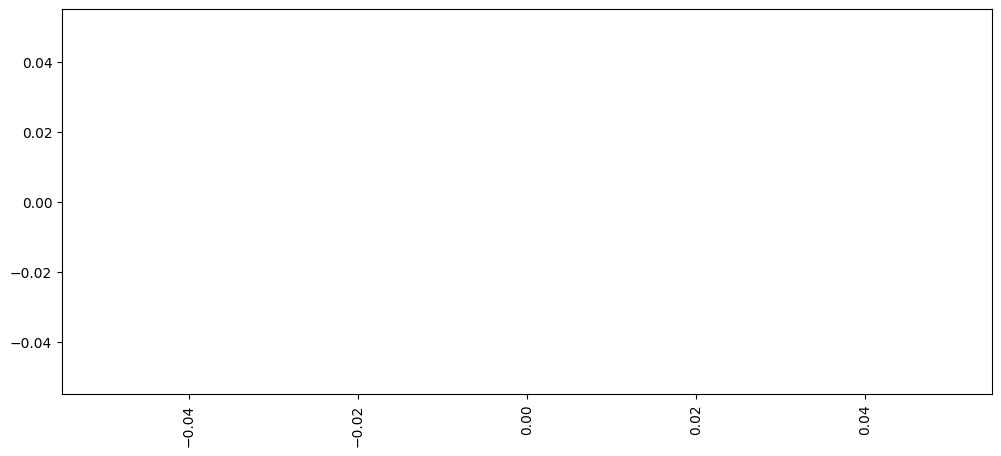

In [52]:
# Create barplot for the monthly average delivery time

monthly_delivery = df_delivery.groupby('month')['delivery_time'].mean()

plt.figure(figsize=(12, 5))
monthly_delivery.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Average delivery time by month')
plt.xlabel('Month')
plt.ylabel('Avg delivery time (days)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## E - Bonus

### 1 - Order distribution by day of week and time of day 

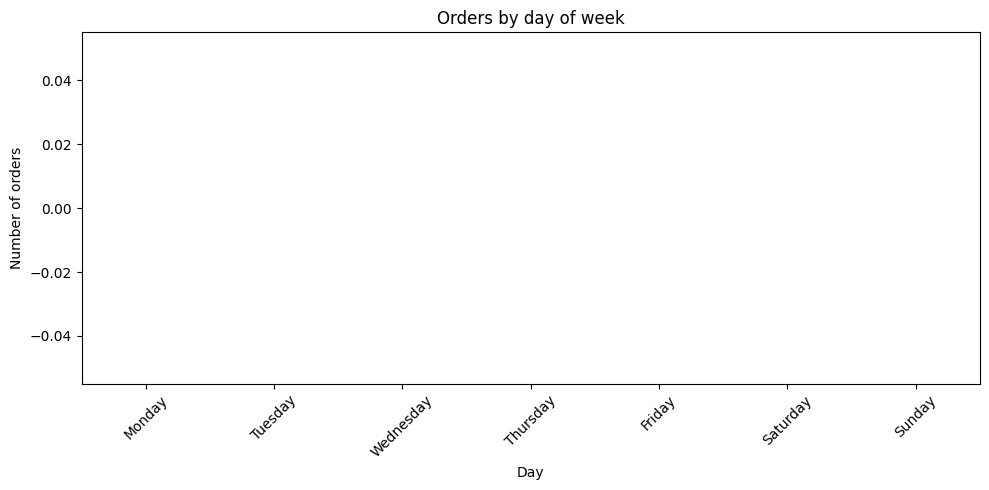

In [53]:
# Count plot showing order distribution by day of week

df['day_name'] = df['day_of_week_int'].apply(
    lambda x: day_names[int(x)-1] if pd.notna(x) and 1 <= x <= 7 else 'Unknown'
)

orders_by_day = df.groupby('day_name')['order_id'].nunique().reindex(day_names)

plt.figure(figsize=(10, 5))
orders_by_day.plot(kind='bar', color='steelblue')
plt.title('Orders by day of week')
plt.xlabel('Day')
plt.ylabel('Number of orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



IndexError: index 0 is out of bounds for axis 0 with size 0

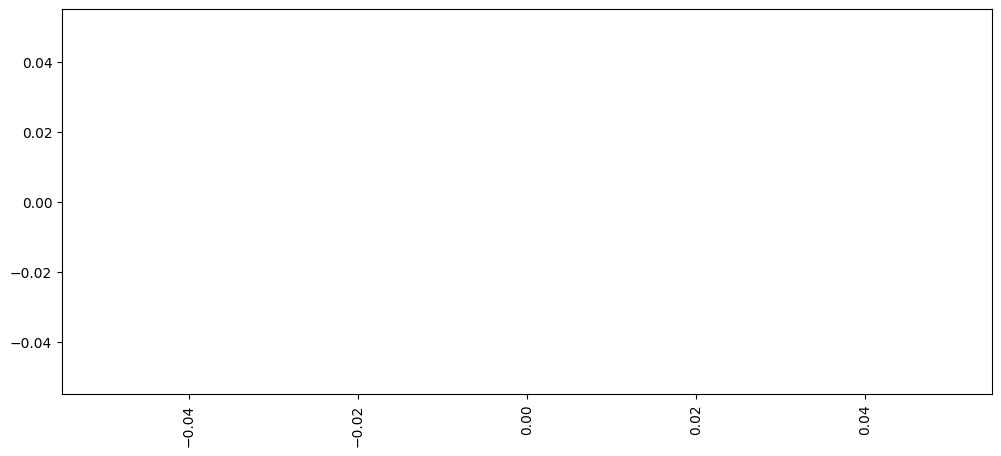

In [54]:
# Count plot showing order distribution by time of day
orders_by_hour = df.groupby('hour')['order_id'].nunique().sort_index()

plt.figure(figsize=(12, 5))
orders_by_hour.plot(kind='bar', color='coral')
plt.title('Orders by hour of day')
plt.xlabel('Hour')
plt.ylabel('Number of orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### 2 - Payments

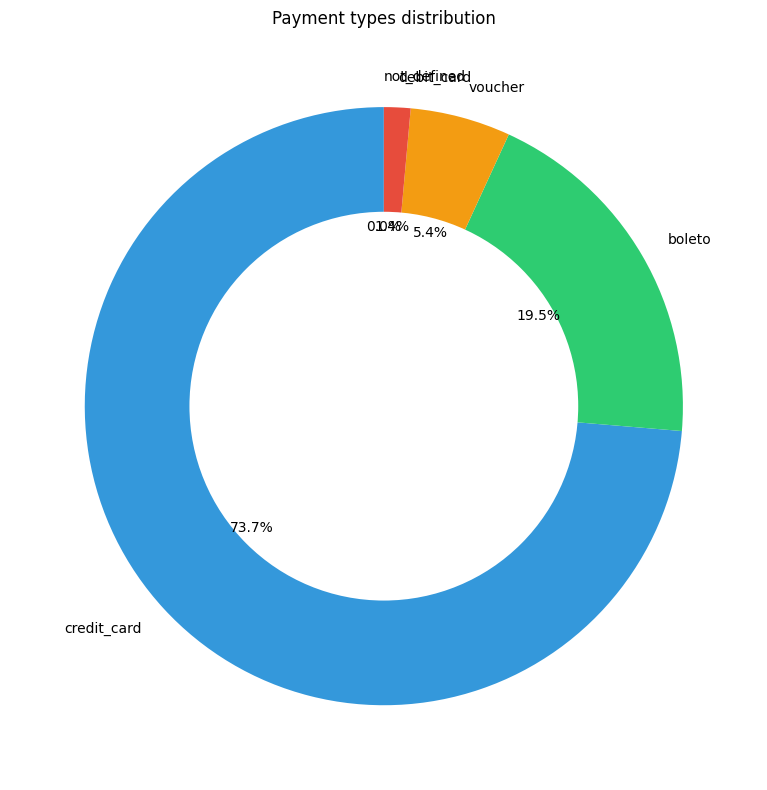

In [55]:
# Create a donut (pie chart) that show transactions by payment types

payment_counts = df['payment_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(payment_counts.values, labels=payment_counts.index,
                                   autopct='%1.1f%%', startangle=90,
                                   colors=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C'])
# make it a donut
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
ax.add_artist(centre_circle)
plt.title('Payment types distribution')
plt.tight_layout()
plt.show()





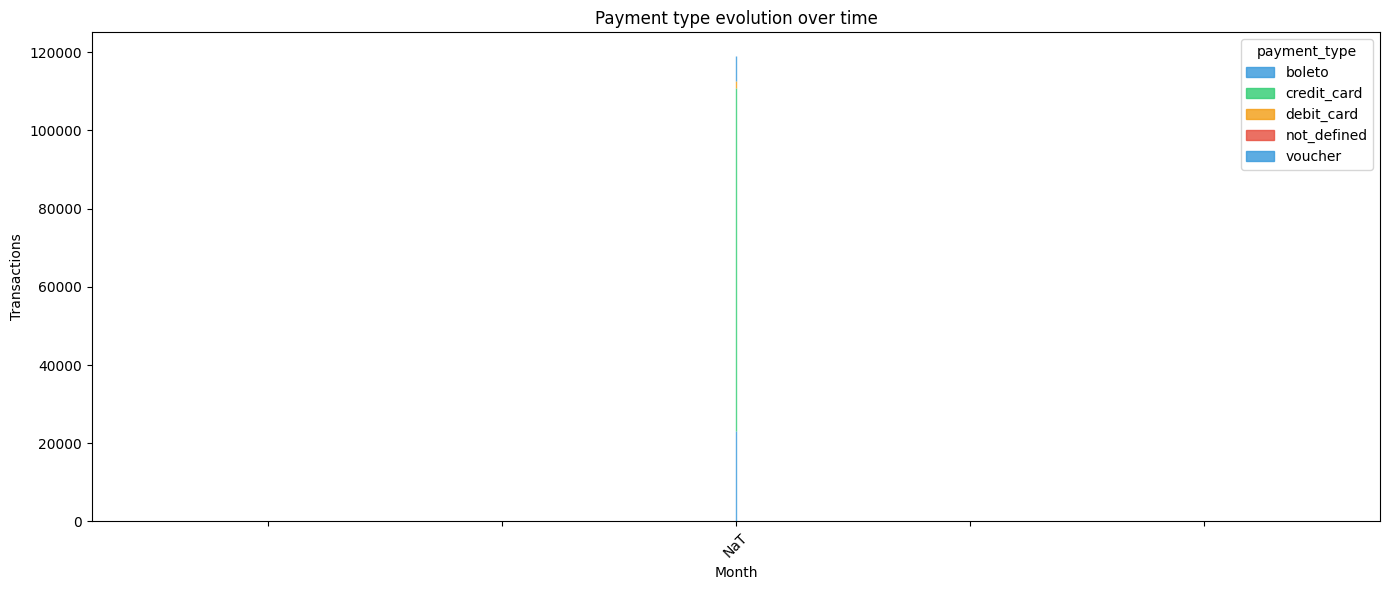

In [56]:
# Show the evolution of payment types over time
payment_evolution = df.groupby(['year_month', 'payment_type'])['order_id'].count().reset_index()
payment_pivot = payment_evolution.pivot(index='year_month', columns='payment_type', values='order_id').fillna(0)

plt.figure(figsize=(14, 6))
payment_pivot.plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.8,
                   color=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C'])
plt.title('Payment type evolution over time')
plt.xlabel('Month')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3 - Geolocation

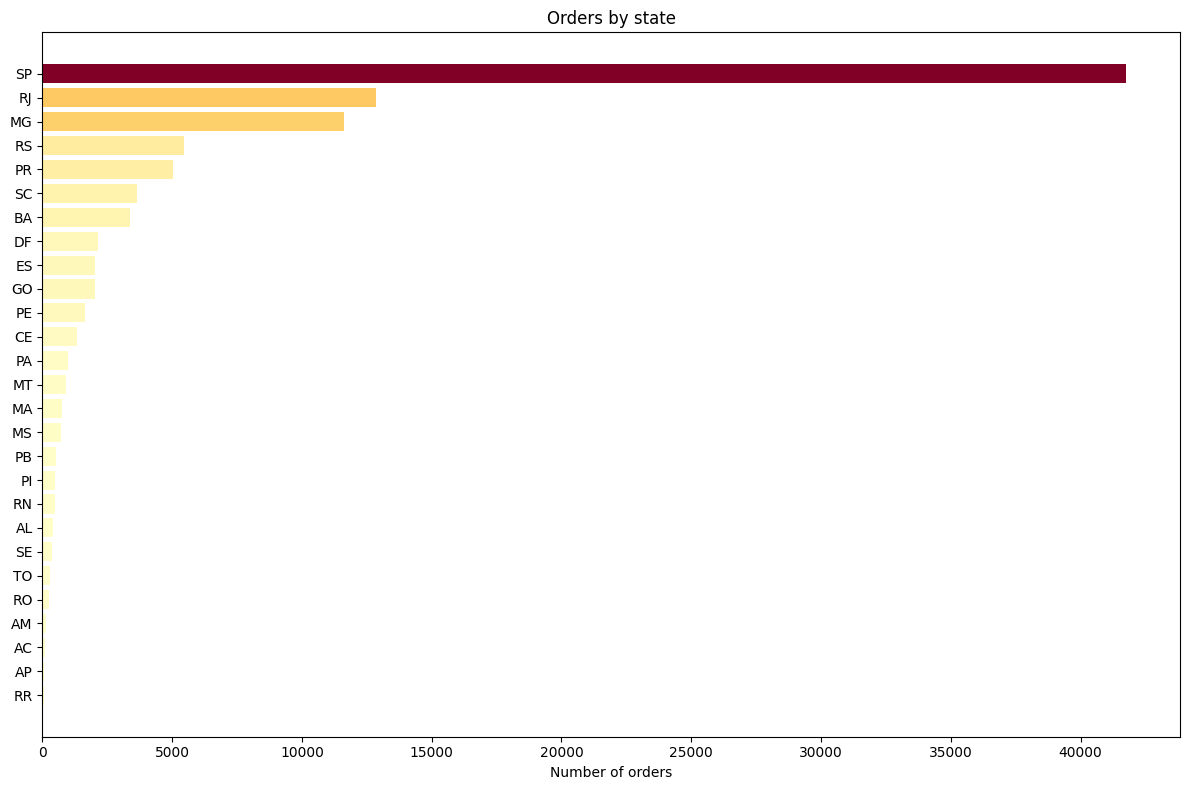

In [57]:
# Create a heatmap of orders by state (using geolocation data)
# we use state-level data since we don't have exact lat/long per order
orders_by_state = df.groupby('customer_state')['order_id'].nunique().reset_index()
orders_by_state.columns = ['state', 'order_count']
orders_by_state = orders_by_state.sort_values('order_count', ascending=True)

plt.figure(figsize=(12, 8))
colors_map = plt.cm.YlOrRd(orders_by_state['order_count'] / orders_by_state['order_count'].max())
plt.barh(orders_by_state['state'], orders_by_state['order_count'], color=colors_map)
plt.title('Orders by state')
plt.xlabel('Number of orders')
plt.tight_layout()
plt.show()


### 4 - Profit computation

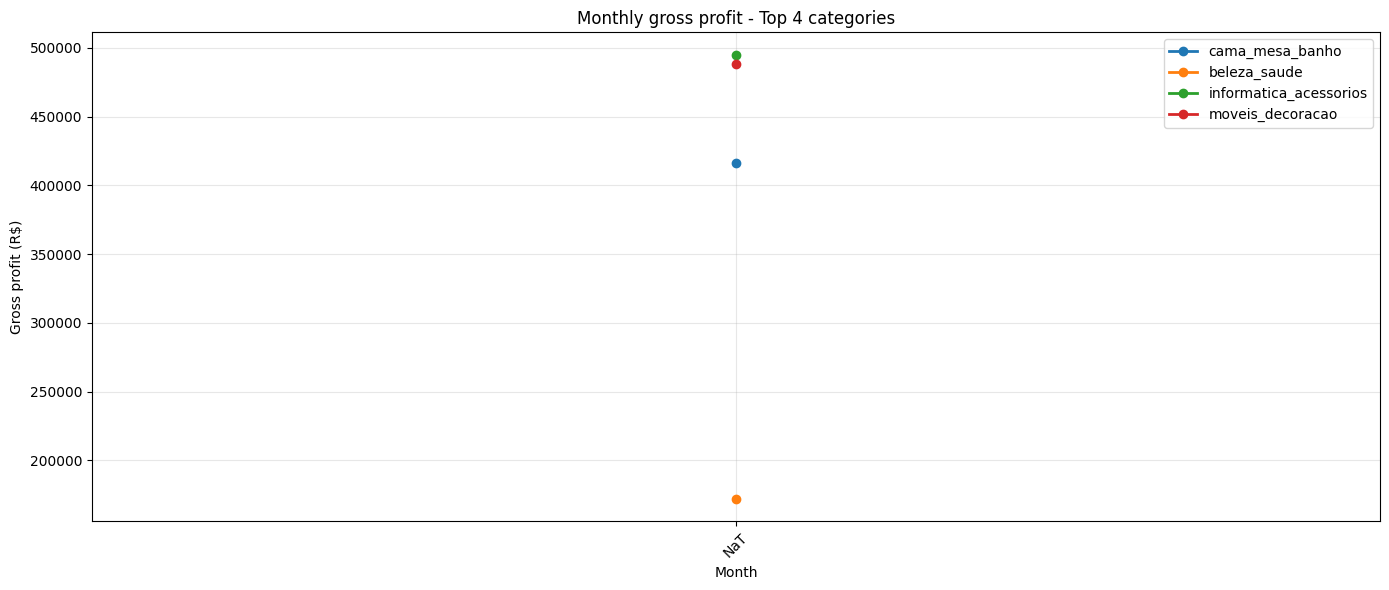

In [58]:

# 4 - Profit computation

# Show the monthly profit evolution for the best 4 product categories
# x axis: months
# y axis: gross profit (payment value - total order value)
# hue : top product categories

df['gross_profit'] = df['payment_value'] - df['order_value']

# get top 4 categories by revenue
top_4 = df.groupby('product_category_name')['payment_value'].sum().nlargest(4).index.tolist()
df_top = df[df['product_category_name'].isin(top_4)]

profit_monthly = df_top.groupby(['year_month', 'product_category_name'])['gross_profit'].sum().reset_index()

plt.figure(figsize=(14, 6))
for cat in top_4:
    cat_data = profit_monthly[profit_monthly['product_category_name'] == cat]
    plt.plot(cat_data['year_month'], cat_data['gross_profit'], marker='o', linewidth=2, label=cat)

plt.title('Monthly gross profit - Top 4 categories')
plt.xlabel('Month')
plt.ylabel('Gross profit (R$)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
